In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
df = pd.read_csv("../data/processed/superstore_clean.csv")
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sub_category,product_name,sales,quantity,discount,profit,shipping_days,order_year,order_month,profit_margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,2016,11,0.1600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,2016,11,0.3000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,2016,6,0.4700
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,2015,10,-0.4000
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,2015,10,0.1125


In [9]:
features = ["sales", "discount", "quantity", "category", "sub_category", "region", "segment"]
target = "profit"

X = df[features].copy()
X["sales_discount_interaction"] = df["sales"] * df["discount"]
y = df[target]

X.head()

,sales,discount,quantity,category,sub_category,region,segment,sales_discount_interaction
0,261.9600,0.00,2,Furniture,Bookcases,South,Consumer,0.000000
1,731.9400,0.00,3,Furniture,Chairs,South,Consumer,0.000000
2,14.6200,0.00,2,Office Supplies,Labels,West,Corporate,0.000000
3,957.5775,0.45,5,Furniture,Tables,South,Consumer,430.909875
4,22.3680,0.20,2,Office Supplies,Storage,South,Consumer,4.473600


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (7995, 7)
Test size: (1999, 7)


In [10]:
categorical_features = ["category", "sub_category", "region", "segment"]
numeric_features = ["sales", "discount", "quantity", "sales_discount_interaction"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])


In [6]:
model.fit(X_train, y_train)
print("Model trained.")


Model trained.


In [7]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MODEL EVALUATION
MAE  : 67.6887
RMSE : 282.4123
R²   : -0.6450


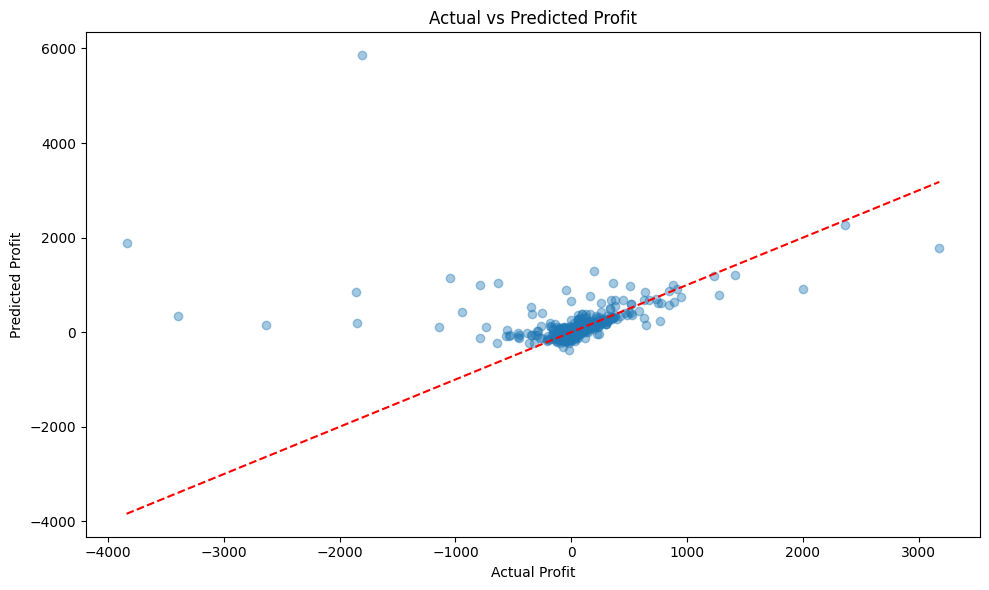

In [8]:
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")
plt.tight_layout()
plt.show()

# Modeling Summary — fill this in with actual MAE/RMSE/R² once Cell 7 runs

# Modeling Summary

## Model Used
Linear Regression, predicting order-level **Profit** from Sales, Discount, Quantity, Category, Sub-Category, Region, and Segment (categorical features one-hot encoded).

## Results
- MAE  : 67.6887
- RMSE : 282.4123
- R²   : -0.6450

## Interpretation
The negative R² indicates that this linear model performs worse than simply predicting the average profit for every order. This suggests that profit is **not well explained by a linear relationship** with these features alone.

A likely explanation is that discount interacts with sales in a non-additive way — high discounts on high-sales orders can produce disproportionately large losses, a pattern linear regression struggles to capture without explicit interaction terms or a non-linear model (e.g., decision tree or random forest regression).

## Conclusion
While the statistical tests in `03_statistical_analysis.ipynb` confirmed a significant correlation between Sales and Profit overall, that relationship is not strong or linear enough to reliably predict individual order profit. This is a useful negative result: it points toward discount policy and category-specific pricing (rather than sales volume alone) as the more actionable levers for improving profitability, consistent with the EDA findings on Furniture and high-discount sub-categories.

## Future Work
A non-linear model (Random Forest or Gradient Boosting Regressor) incorporating sales-discount interaction terms could likely improve predictive performance and would be a natural next step beyond this project's scope.